In [1]:
from pathlib import Path

import pandas as pd

from sklearn.model_selection import train_test_split

In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

metadata_csv = (
    PROCESSED_DIR
    / "eurosat_geo_clusters.csv"
)

metadata_df = pd.read_csv(metadata_csv)

print(metadata_df.shape)

metadata_df.head()

(27000, 7)


,filepath_rgb,filepath_tif,class_name,center_lat,center_lon,class_id,geo_cluster
0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,44.035220,28.559055,0,3
1,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,39.085801,-1.829726,0,5
2,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,48.977295,4.239720,0,2
3,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,48.892610,4.089878,0,2
4,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,51.832851,18.084960,0,6


In [3]:
metadata_df = metadata_df[
    [
        "filepath_rgb",
        "filepath_tif",
        "class_name",
        "class_id",
        "center_lat",
        "center_lon"
    ]
].copy()

metadata_df.head()

,filepath_rgb,filepath_tif,class_name,class_id,center_lat,center_lon
0,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,0,44.035220,28.559055
1,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,0,39.085801,-1.829726
2,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,0,48.977295,4.239720
3,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,0,48.892610,4.089878
4,c:\Users\ASUS\dev\projects\satellite-project\d...,c:\Users\ASUS\dev\projects\satellite-project\d...,AnnualCrop,0,51.832851,18.084960


In [4]:
train_df, temp_df = train_test_split(

    metadata_df,

    test_size=0.30,

    random_state=42,

    stratify=metadata_df["class_id"]

)

print(len(train_df))
print(len(temp_df))

18900
8100


In [5]:
val_df, test_df = train_test_split(

    temp_df,

    test_size=0.50,

    random_state=42,

    stratify=temp_df["class_id"]

)

print(len(train_df))
print(len(val_df))
print(len(test_df))

18900
4050
4050


In [6]:
print("Train")
display(
    train_df["class_name"]
    .value_counts()
    .sort_index()
)

print()

print("Validation")
display(
    val_df["class_name"]
    .value_counts()
    .sort_index()
)

print()

print("Test")
display(
    test_df["class_name"]
    .value_counts()
    .sort_index()
)

Train


class_name
AnnualCrop              2100
Forest                  2100
HerbaceousVegetation    2100
Highway                 1750
Industrial              1750
Pasture                 1400
PermanentCrop           1750
Residential             2100
River                   1750
SeaLake                 2100
Name: count, dtype: int64


Validation


class_name
AnnualCrop              450
Forest                  450
HerbaceousVegetation    450
Highway                 375
Industrial              375
Pasture                 300
PermanentCrop           375
Residential             450
River                   375
SeaLake                 450
Name: count, dtype: int64


Test


class_name
AnnualCrop              450
Forest                  450
HerbaceousVegetation    450
Highway                 375
Industrial              375
Pasture                 300
PermanentCrop           375
Residential             450
River                   375
SeaLake                 450
Name: count, dtype: int64

In [7]:
train_csv = (
    PROCESSED_DIR
    / "train_random.csv"
)

val_csv = (
    PROCESSED_DIR
    / "validation_random.csv"
)

test_csv = (
    PROCESSED_DIR
    / "test_random.csv"
)

train_df.to_csv(
    train_csv,
    index=False
)

val_df.to_csv(
    val_csv,
    index=False
)

test_df.to_csv(
    test_csv,
    index=False
)

print("Saved:")
print(train_csv)
print(val_csv)
print(test_csv)

Saved:
c:\Users\ASUS\dev\projects\satellite-project\data\processed\train_random.csv
c:\Users\ASUS\dev\projects\satellite-project\data\processed\validation_random.csv
c:\Users\ASUS\dev\projects\satellite-project\data\processed\test_random.csv


In [8]:
for file in [
    train_csv,
    val_csv,
    test_csv
]:

    df = pd.read_csv(file)

    print(file.name)
    print(df.shape)
    print()

train_random.csv
(18900, 6)

validation_random.csv
(4050, 6)

test_random.csv
(4050, 6)



In [9]:
from pathlib import Path

import pandas as pd

from PIL import Image

import torch

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision import transforms

In [10]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = (
    PROJECT_ROOT
    / "data"
)

PROCESSED_DIR = (
    DATA_DIR
    / "processed"
)

train_csv = (
    PROCESSED_DIR
    / "train_random.csv"
)

val_csv = (
    PROCESSED_DIR
    / "validation_random.csv"
)

test_csv = (
    PROCESSED_DIR
    / "test_random.csv"
)

print(train_csv.exists())
print(val_csv.exists())
print(test_csv.exists())

True
True
True


In [11]:
class EuroSATDataset(Dataset):

    def __init__(
        self,
        csv_file,
        transform=None
    ):

        self.df = pd.read_csv(csv_file)

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = Image.open(
            row["filepath_rgb"]
        ).convert("RGB")

        label = int(
            row["class_id"]
        )

        if self.transform:

            image = self.transform(image)

        return image, label

In [12]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomVerticalFlip(),

    transforms.RandomRotation(20),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])

eval_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485,0.456,0.406],

        std=[0.229,0.224,0.225]

    )

])

In [13]:
train_dataset = EuroSATDataset(

    train_csv,

    transform=train_transform

)

val_dataset = EuroSATDataset(

    val_csv,

    transform=eval_transform

)

test_dataset = EuroSATDataset(

    test_csv,

    transform=eval_transform

)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

18900
4050
4050


In [14]:
BATCH_SIZE = 64

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0

)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

)

In [15]:
images, labels = next(
    iter(train_loader)
)

print(images.shape)

print(labels.shape)

print(images.dtype)

torch.Size([64, 3, 224, 224])
torch.Size([64])
torch.float32


In [16]:
import copy

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models

from tqdm.auto import tqdm

In [17]:
DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print(DEVICE)

cuda


In [18]:
CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "checkpoints"
)

CHECKPOINT_DIR.mkdir(
    exist_ok=True
)

FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
)

CONFUSION_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "confusion_matrices"
)

In [19]:
resnet18 = models.resnet18(

    weights=models.ResNet18_Weights.DEFAULT

)

for param in resnet18.parameters():

    param.requires_grad = False

resnet18.fc = nn.Linear(

    resnet18.fc.in_features,

    10

)

resnet18 = resnet18.to(DEVICE)

resnet18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [20]:
total_params = sum(

    p.numel()

    for p in resnet18.parameters()

)

trainable_params = sum(

    p.numel()

    for p in resnet18.parameters()

    if p.requires_grad

)

print(f"Total Parameters: {total_params:,}")

print(f"Trainable Parameters: {trainable_params:,}")

Total Parameters: 11,181,642
Trainable Parameters: 5,130


In [21]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(

    resnet18.fc.parameters(),

    lr=1e-3

)

In [22]:
class EarlyStopping:

    def __init__(
        self,
        patience=5,
        min_delta=0.0
    ):

        self.patience = patience
        self.min_delta = min_delta

        self.best_loss = float("inf")
        self.counter = 0

        self.early_stop = False

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:

            self.best_loss = val_loss
            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

In [27]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss
        / len(loader)
    )

    epoch_acc = (
        correct
        / total
    )

    return epoch_loss, epoch_acc

In [28]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    epoch_loss = (
        running_loss
        / len(loader)
    )

    epoch_acc = (
        correct
        / total
    )

    return epoch_loss, epoch_acc

In [29]:
EPOCHS = 20

PATIENCE = 5

early_stopping = EarlyStopping(

    patience=PATIENCE

)

best_val_loss = float("inf")

best_model = None

train_losses = []

val_losses = []

train_accs = []

val_accs = []

In [30]:
for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        resnet18,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = evaluate(
        resnet18,
        val_loader,
        criterion,
        DEVICE
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Acc : {train_acc:.4f}")
    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val Acc   : {val_acc:.4f}")
    print("-" * 50)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            resnet18.state_dict(),
            CHECKPOINT_DIR / "resnet18_random_best.pt"
        )

        print(
            f"Saved new best model (Val Loss = {val_loss:.4f})"
        )

    early_stopping(val_loss)

    if early_stopping.early_stop:

        print(
            f"Early stopping triggered at epoch {epoch+1}"
        )

        break

print(
    f"Best Validation Loss: {best_val_loss:.4f}"
)

  0%|          | 0/296 [00:00<?, ?it/s]

Epoch [1/20]
Train Loss: 0.7954
Train Acc : 0.7773
Val Loss  : 0.5378
Val Acc   : 0.8375
--------------------------------------------------
Saved new best model (Val Loss = 0.5378)


  0%|          | 0/296 [00:00<?, ?it/s]

Epoch [2/20]
Train Loss: 0.4211
Train Acc : 0.8717
Val Loss  : 0.4344
Val Acc   : 0.8585
--------------------------------------------------
Saved new best model (Val Loss = 0.4344)


  0%|          | 0/296 [00:00<?, ?it/s]

...

Epoch [11/20]
Train Loss: 0.2711
Train Acc : 0.9084
Val Loss  : 0.3251
Val Acc   : 0.8857
--------------------------------------------------


  0%|          | 0/296 [00:00<?, ?it/s]

Epoch [12/20]
Train Loss: 0.2691
Train Acc : 0.9077
Val Loss  : 0.2952
Val Acc   : 0.8993
--------------------------------------------------


  0%|          | 0/296 [00:00<?, ?it/s]

Epoch [13/20]
Train Loss: 0.2662
Train Acc : 0.9101
Val Loss  : 0.3129
Val Acc   : 0.8916
--------------------------------------------------
Early stopping triggered at epoch 13
Best Validation Loss: 0.2890


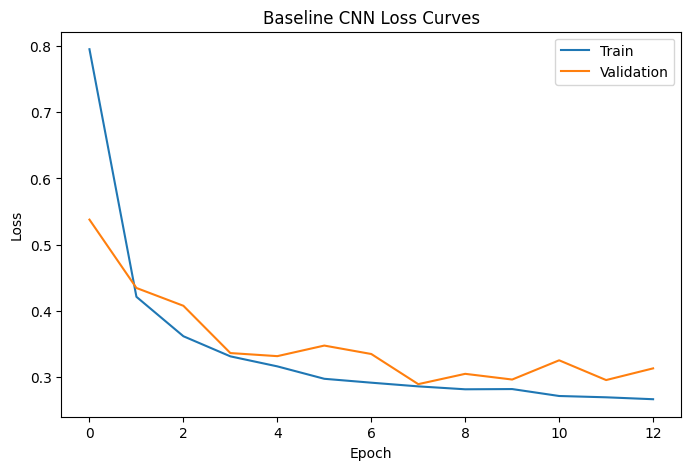

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train"
)

plt.plot(
    val_losses,
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.title(
    "Baseline CNN Loss Curves"
)

plt.show()

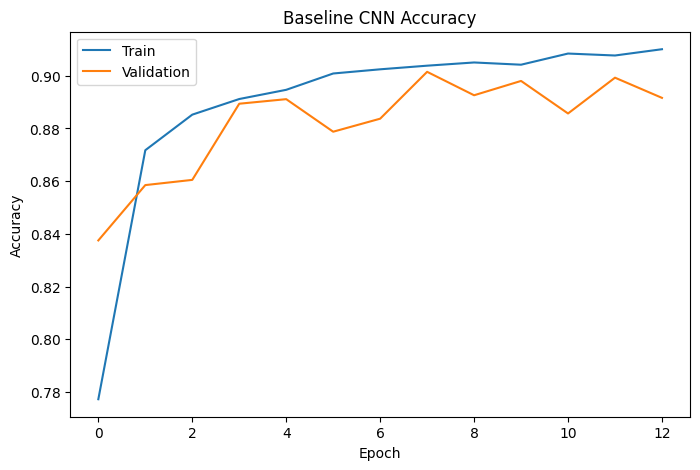

In [32]:
plt.figure(figsize=(8,5))

plt.plot(
    train_accs,
    label="Train"
)

plt.plot(
    val_accs,
    label="Validation"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.title(
    "Baseline CNN Accuracy"
)

plt.show()

In [33]:
images, labels = next(iter(train_loader))

images = images.to(DEVICE)

with torch.no_grad():
    outputs = resnet18(images)

print(outputs.shape)

torch.Size([64, 10])


In [34]:
best_model = copy.deepcopy(
    resnet18.state_dict()
)

In [35]:
resnet18.load_state_dict(

    best_model

)

print("Loaded best model.")

resnet18.eval()

Loaded best model.


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [36]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

import matplotlib.pyplot as plt

In [37]:
all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = resnet18(images)

        preds = outputs.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

all_preds = np.array(all_preds)

all_labels = np.array(all_labels)

print(len(all_preds))
print(len(all_labels))

4050
4050


In [38]:
accuracy = accuracy_score(
    all_labels,
    all_preds
)

macro_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

print(
    f"Test Accuracy: {accuracy:.4f}"
)

print(
    f"Macro F1: {macro_f1:.4f}"
)

Test Accuracy: 0.8872
Macro F1: 0.8836


In [39]:
label_map = {
    0:"AnnualCrop",
    1:"Forest",
    2:"HerbaceousVegetation",
    3:"Highway",
    4:"Industrial",
    5:"Pasture",
    6:"PermanentCrop",
    7:"Residential",
    8:"River",
    9:"SeaLake"
}

In [40]:
class_names = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

In [41]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(
    report
).transpose()

report_df

,precision,recall,f1-score,support
AnnualCrop,0.933806,0.877778,0.904926,450.00000
Forest,0.964602,0.968889,0.966741,450.00000
HerbaceousVegetation,0.938953,0.717778,0.813602,450.00000
Highway,0.780723,0.864000,0.820253,375.00000
Industrial,0.884058,0.976000,0.927757,375.00000
Pasture,0.830816,0.916667,0.871632,300.00000
PermanentCrop,0.733042,0.893333,0.805288,375.00000
Residential,0.925054,0.960000,0.942203,450.00000
River,0.880734,0.768000,0.820513,375.00000
SeaLake,0.997619,0.931111,0.963218,450.00000


In [42]:
report_path = (
    FIGURE_DIR
    / "resnet18_random_classification_report.csv"
)

report_df.to_csv(
    report_path
)

print(report_path)

c:\Users\ASUS\dev\projects\satellite-project\outputs\figures\resnet18_random_classification_report.csv


In [43]:
per_class_f1 = report_df[
    ["f1-score"]
].iloc[:10]

per_class_f1

,f1-score
AnnualCrop,0.904926
Forest,0.966741
HerbaceousVegetation,0.813602
Highway,0.820253
Industrial,0.927757
Pasture,0.871632
PermanentCrop,0.805288
Residential,0.942203
River,0.820513
SeaLake,0.963218


In [44]:
f1_path = (
    FIGURE_DIR
    / "resnet18_random_per_class_f1.csv"
)

per_class_f1.to_csv(
    f1_path
)

print(f1_path)

c:\Users\ASUS\dev\projects\satellite-project\outputs\figures\resnet18_random_per_class_f1.csv


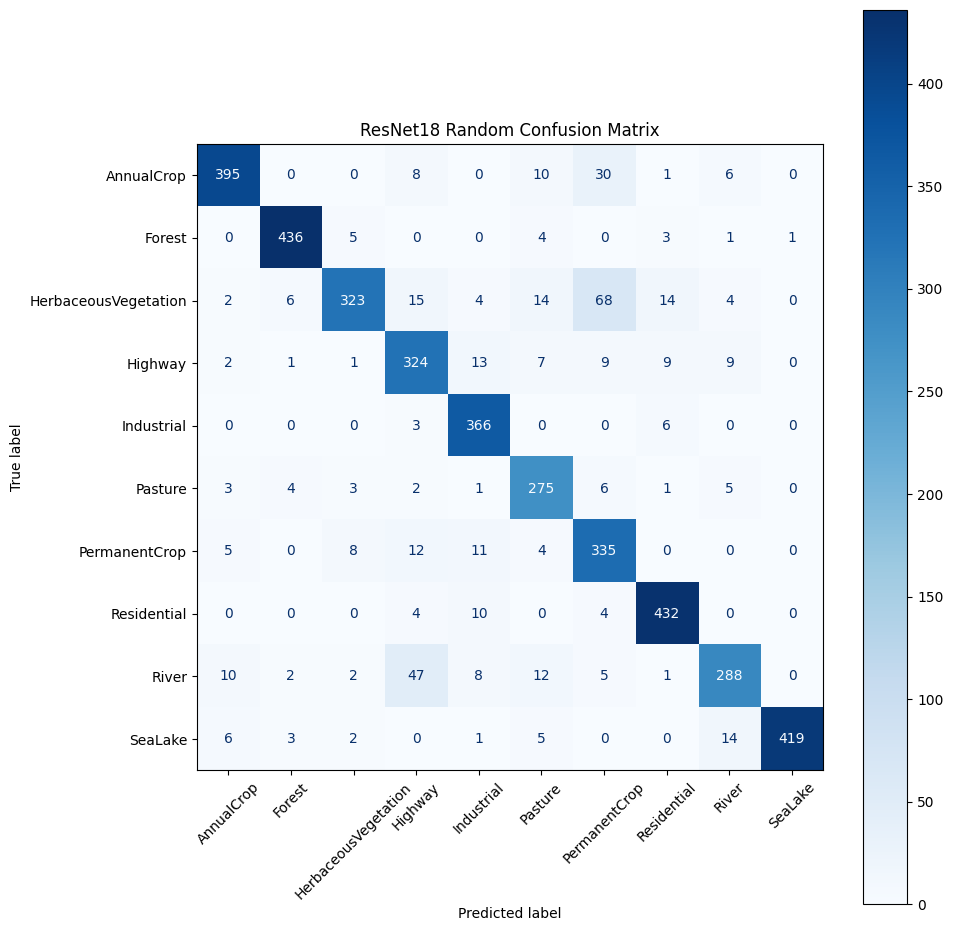

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_preds
)

fig, ax = plt.subplots(
    figsize=(10,10)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

plt.title(
    "ResNet18 Random Confusion Matrix"
)

plt.tight_layout()

In [46]:
cm_path = (
    CONFUSION_DIR
    / "resnet18_random_confusion_matrix.png"
)

plt.savefig(
    cm_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(cm_path)

<Figure size 640x480 with 0 Axes>

c:\Users\ASUS\dev\projects\satellite-project\outputs\confusion_matrices\resnet18_random_confusion_matrix.png


In [47]:
summary = pd.DataFrame(
    {
        "Metric":[
            "Accuracy",
            "Macro_F1"
        ],
        "Value":[
            accuracy,
            macro_f1
        ]
    }
)

summary_path = (
    FIGURE_DIR
    / "resnet18_random_metrics.csv"
)

summary.to_csv(
    summary_path,
    index=False
)   

summary

,Metric,Value
0,Accuracy,0.887160
1,Macro_F1,0.883613
